# Overview

The goal of this notebook is to simulate an ARFIMA((1,1,1)) process over a long time horizon and then apply López de Prado’s method to estimate the minimum fractional differentiation order $d^*$. This parameter is interpreted as the smallest degree of differencing that yields an approximately stationary series.

In this project, we aim to show that the value $d^*$ obtained through this procedure is **not** sufficient to produce a truly stationary process. To demonstrate this empirically, we will train predictive models on the fractionally differentiated series and evaluate their performance across multiple future test sets—**test1**, **test2**, …, **test10**—chosen at increasingly distant horizons.

Our working hypothesis is the following:

* The original ARFIMA process remains **non-stationary** even after differentiation at order $d^*$.
* Consequently, the series retains a **residual drift**.
* Machine learning models fitted on past data **learn this drift**.

In this notebook we will use only the **one-step-ahead forecasting approach**. In the previous notebook, we showed that combining the sliding-window method with fractional differentiation does not provide meaningful improvements, so we will not adopt it here.


In [1]:
# We download historical S&P 500 data to understand the typical sample size available.
# This will guide us in simulating a time series of comparable length.
# import yfinance as yf
# sp500_data = yf.download('^GSPC', start='1900-01-01')

# Import necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from fracdiff.sklearn import Fracdiff
from statsmodels.tsa.stattools import adfuller
from mypackage_utils import *
#from statsmodels.tsa.arima_process import ArmaProcess
# For reproducibility
np.random.seed(42) 

ADF Statistic: -1.6311155211262092
p-value: 0.46690685887851946


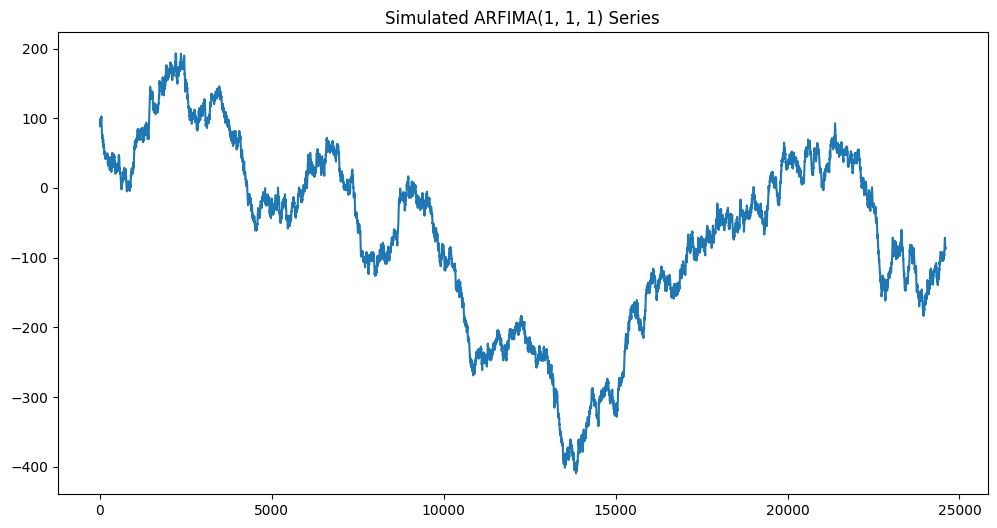

In [2]:
import arfima
# ARFIMA( p, d, q ) process generation \phi(B),(1-B)^{d} X_t = \theta(B),\varepsilon_t 
available_data = 24593
# Fractional differencing parameter
d = 1
# AR(1) coefficient
phi = [0.3]      
# MA(1) coefficient
theta = [0.5] 
arfima_series = arfima.arfima(phi, d, theta, available_data, warmup=available_data)
plt.figure(figsize=(12, 6))
plt.title(f"Simulated ARFIMA(1, {d}, 1) Series")
plt.plot(arfima_series)
# Stationarity according to ADF test
adf_result = adfuller(arfima_series)
print(f"ADF Statistic: {adf_result[0]}")
print(f"p-value: {adf_result[1]}")


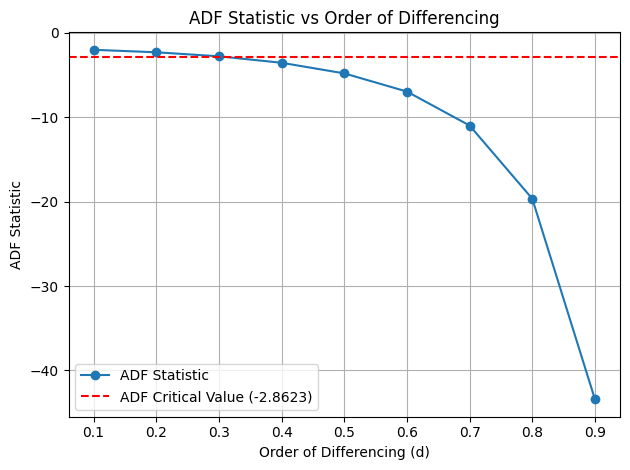

Estimated order of stationarity : ~ 0.312


In [3]:
# Find the best order of differentiation for a non-stationary ARFIMA in order to make it stationary. 
# Plot the ADF results vs order of differentiation
d_grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

cval = -2.8623  # ADF critical value at 5% for n > 1000
window_size = 10
rows = []
for d in d_grid:
	frac = Fracdiff(d, window=window_size, window_policy="fixed") 	# the window size is now default=10   
	X = arfima_series.reshape(-1, 1)     
	X_fd = frac.fit_transform(X).ravel()
	X_fd[:(window_size - 1)] = np.nan
	s_fd = pd.Series(X_fd)        								
	a_stat, a_p, _ , _ = stationarity_values(s_fd)
	rows.append({
		"d": d, "series": s_fd,
		"adf_stat": a_stat, "adf_p": a_p,
	})
d_values = [r['d'] for r in rows]
adf_stats = [r['adf_stat'] for r in rows]
plt.title(f"ADF Statistic vs Order of Differencing")
plt.plot(d_values, adf_stats, marker='o', label='ADF Statistic')
plt.axhline(y=cval, color='r', linestyle='--', label='ADF Critical Value (-2.8623)')
plt.xlabel("Order of Differencing (d)")
plt.ylabel("ADF Statistic")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
# Intersection between ADF stats and critical value
# find first crossing where ADF goes from > cval to <= cval
d_values  = np.asarray(d_values, dtype=float)
adf_stats = np.asarray(adf_stats, dtype=float)
mask = (adf_stats[:-1] > cval) & (adf_stats[1:] <= cval)
idx = np.where(mask)[0]
i = idx[0]
# linear interpolation
d1, d2 = d_values[i], d_values[i+1]
a1, a2 = adf_stats[i], adf_stats[i+1]
d_star = d1 + (cval - a1) * (d2 - d1) / (a2 - a1)
print(f"Estimated order of stationarity : ~ {d_star:.3f}")



We simulate an ARFIMA $(p,d,q)$ process, meaning that the generated time series $X_t$ satisfies
\begin{equation}
\varphi(B)(1-B)^{d} X_t = \theta(B) Z_t.
\end{equation}
Equivalently,
\begin{equation}
X_t = (1-B)^{-d}\left(\varphi(B)^{-1}\theta(B)Z_t\right).
\end{equation}

From theory, if $d > \tfrac12$ then the process $X_t$ is non–stationary.
To emulate this setting, we choose such a value of $d$ and apply fractional differentiation: 
\begin{equation}
(1-B)^{d^*} X_t = (1-B)^{d^* - d}\varphi(B)^{-1}\theta(B)Z_t .
\end{equation}

Defining
\begin{equation}
Y_t := (1-B)^{d^*} X_t,
\end{equation}
the equation becomes
\begin{equation}
\varphi(B)(1-B)^{d - d^*}Y_t = \theta(B)Z_t .
\end{equation}

Thus $Y_t$ is itself an ARFIMA time series with parameter $d - d^*$ .
If $d - d^* > \tfrac12$, then the transformed process is still non–stationary.


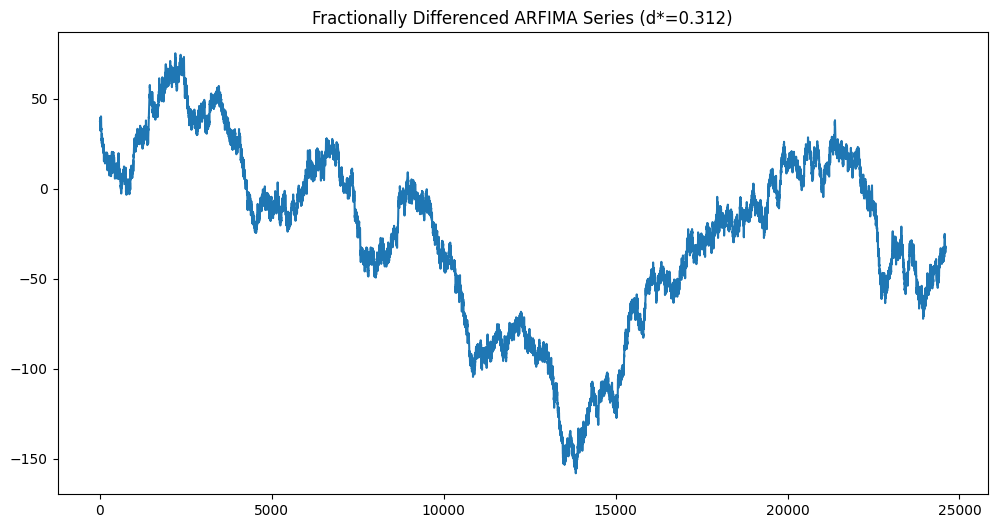

In [4]:
# Determine the fractionally differenced series using the estimated d_star
fd_arfima = Fracdiff(d=d_star, window=window_size, window_policy="fixed")
dataset = fd_arfima.fit_transform(arfima_series.reshape(-1, 1)).ravel()
dataset[:(window_size - 1)] = np.nan
plt.figure(figsize=(12, 6))
plt.title(f"Fractionally Differenced ARFIMA Series (d*={d_star:.3f})")
plt.plot(dataset)
plt.show()


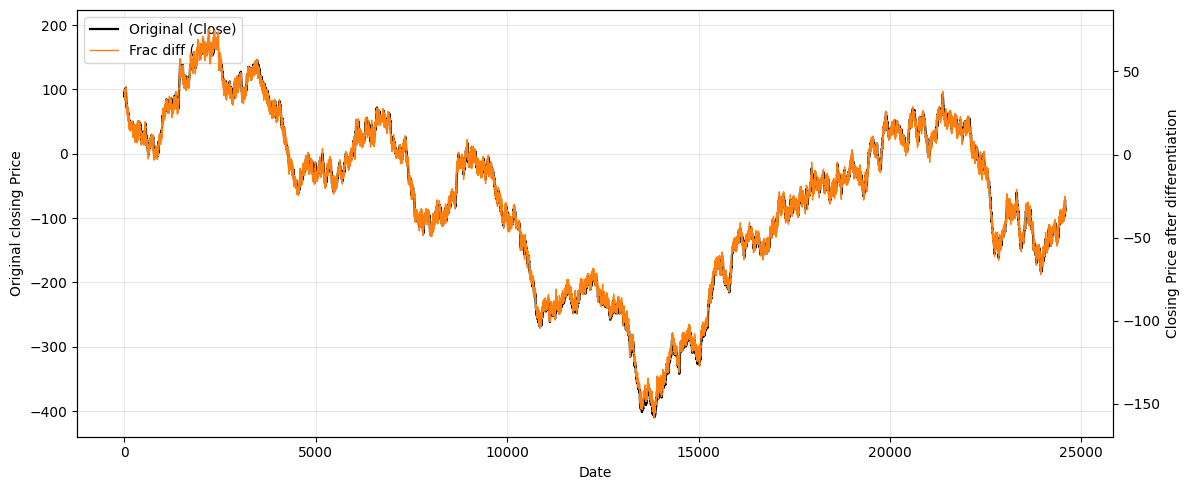

In [5]:
#Plot the original, integer-differenced, and fractionally differenced series on the same figure using twin y-axes.
#Left axis → original series.
#Right axis → differenced series (integer + fractional).

fig, ax1 = plt.subplots(figsize=(12, 5))

# Left axis: original prices 
ax1.plot( arfima_series, lw=1.6, color="black", label="Original (Close)")
ax1.set_ylabel("Original closing Price")
ax1.set_xlabel("Date")

# Right axis: integer and fractional differences 
ax2 = ax1.twinx()
ax2.plot( dataset, lw=1.0, color="tab:orange", label="Frac diff (d*)")
ax2.set_ylabel("Closing Price after differentiation")

# Legend 
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="upper left")

ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Regression problem using NN

In [6]:
# If we interpret the simulated ARFIMA as the log prices, we can compute the log-return simply differentiating
# Prepare dataset for ML
target = np.diff(arfima_series)
mask = np.isfinite(dataset[:-1]) & np.isfinite(target)
X = dataset[:-1][mask].reshape(-1, 1)
y = target[mask].reshape(-1, 1)
# Normalize data (since the target are just the next-day prices, we scale them too)
scaler_data = StandardScaler()

# Split the data into training and testing sets
train_size = int(len(X) * 0.70)
test_size = int(len(X) * 0.03)
train_data = X[:train_size]
target_train = y[:train_size]
train_data = scaler_data.fit_transform(train_data)
test_data = []
target_test = []
for i in range(10):
	test_data.append(scaler_data.transform(X[train_size + i * test_size:train_size + (i + 1) * test_size]))
	target_test.append(y[train_size + i * test_size:train_size + (i + 1) * test_size])


100%|██████████| 500/500 [00:19<00:00, 25.97it/s, lr=0.0001, train=1.71]


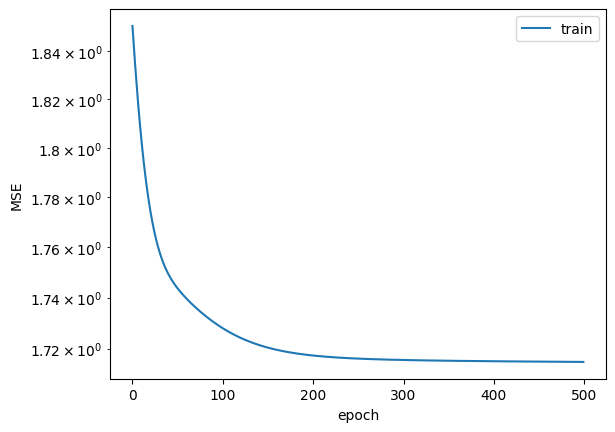

In [7]:
# Define the MLP model
batch_size = 512
nhidden = 4
model = nn.Sequential(nn.Linear(1, nhidden),
						nn.ReLU(),
						nn.Linear(nhidden, 1))

# Transforming data into tensor
train_data = torch.as_tensor(train_data, dtype=torch.float32)
target_train = torch.as_tensor(target_train, dtype=torch.float32).view(-1, 1)
for i in range (10):
	test_data[i] = torch.as_tensor(test_data[i], dtype=torch.float32)
	target_test[i] = torch.as_tensor(target_test[i], dtype=torch.float32).view(-1, 1)

# Dataset e DataLoader
train_dataset = TensorDataset(train_data, target_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # Shuffle False because of time series data

# Defining loss, optimizer 
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Training loop
n_epochs = 500
train_curve= []
training_loop = tqdm(range(n_epochs)) 

for epoch in training_loop:
	# Training mode
	model.train() 
	running = 0.0 
	for batch_data, batch_targets in train_loader:
		# Reset computation graph
		optimizer.zero_grad()
		# Forward pass
		outputs = model(batch_data)
		# Compute training loss on batch
		loss = criterion(outputs, batch_targets)
		# Compute gradient 
		loss.backward()
		# Gradient step
		optimizer.step()
		# Loss per batch 
		running += loss.item()
	# Loss per epoch
	train_epoch = running/len(train_loader)

	# Store train and validation loss
	train_curve.append(train_epoch)

	# Print loss in the progression bar
	training_loop.set_postfix(train=train_epoch,  lr=optimizer.param_groups[0]['lr'])

# Plot losses
plt.figure()
plt.plot(train_curve, label='train')
plt.yscale('log') 
plt.legend(); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.show()			


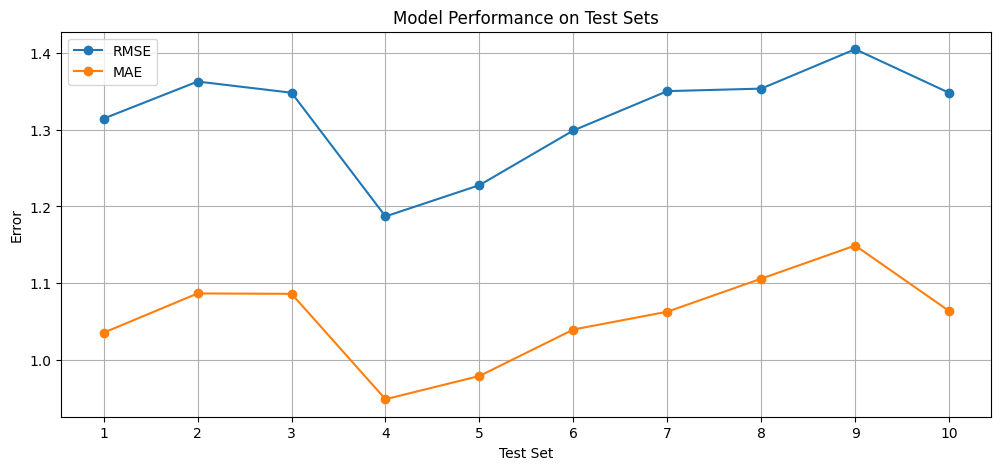

In [8]:
# Metrics evaluation 
rmse_list_nn = []
mae_list_nn = []
loss_list_nn = []
model.eval()
with torch.no_grad():
	for i in range(10):
		predictions = model(test_data[i]).numpy() 
		loss_list_nn.append(mean_squared_error(target_test[i].numpy(), predictions))
		rmse_list_nn.append(np.sqrt(loss_list_nn[-1]))
		mae_list_nn.append(mean_absolute_error(target_test[i].numpy(), predictions))
# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_nn, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_nn, marker='o', label='MAE')
plt.title("Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()


# Regression problem using LR

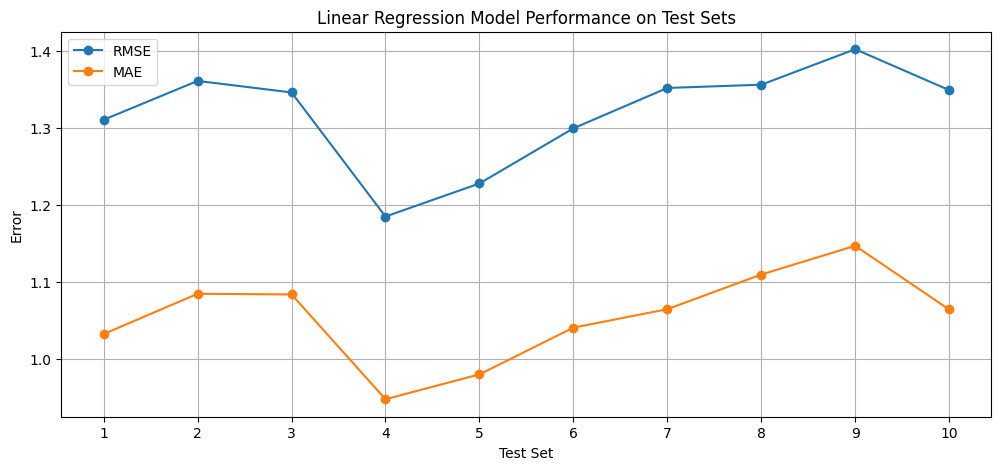

In [9]:
model_lr = LinearRegression()
model_lr.fit(train_data, target_train)
# Save the linear regression model
#joblib.dump(model, weight_filename)
rmse_list_lr = []
mae_list_lr = []
# Evaluate model 
for i in range(10):
	pred = model_lr.predict(test_data[i])
	rmse_list_lr.append(np.sqrt(mean_squared_error(target_test[i].numpy(), pred)))
	mae_list_lr.append(mean_absolute_error(target_test[i].numpy(), pred))
	
# Plot the metric evaluation on the 10 test sets
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_lr, marker='o', label='RMSE')
plt.plot(range(1, 11), mae_list_lr, marker='o', label='MAE')
plt.title("Linear Regression Model Performance on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

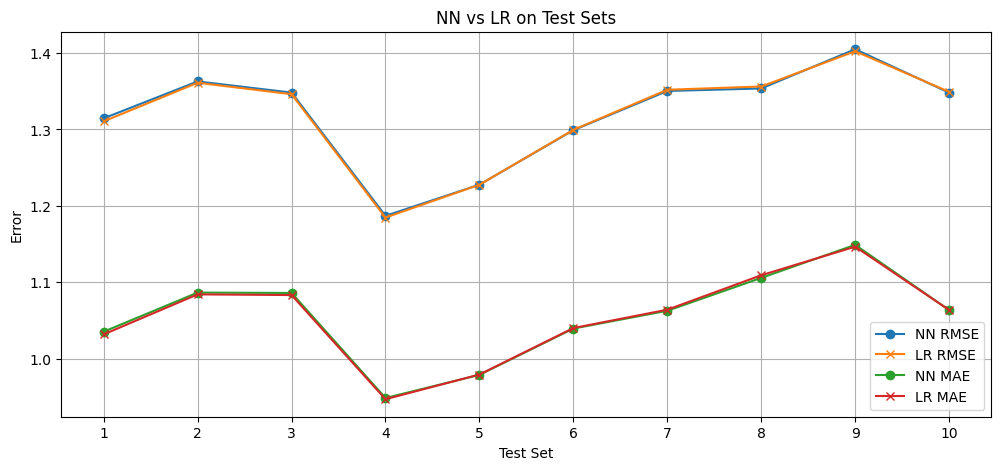

In [10]:
# Compare NN and LR performance plotting both metrics on the same figure
plt.figure(figsize=(12, 5))
plt.plot(range(1, 11), rmse_list_nn, marker='o', label='NN RMSE')
plt.plot(range(1, 11), rmse_list_lr, marker='x', label='LR RMSE')
plt.plot(range(1, 11), mae_list_nn, marker='o', label='NN MAE')
plt.plot(range(1, 11), mae_list_lr, marker='x', label='LR MAE')
plt.title("NN vs LR on Test Sets")
plt.xlabel("Test Set")
plt.ylabel("Error")
plt.xticks(range(1, 11))
plt.legend()
plt.grid()
plt.show()

